In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from helpr.api import CrackEvolutionAnalysis
from helpr.utilities.unit_conversion import convert_psi_to_mpa, convert_in_to_m

from probabilistic.capabilities.uncertainty_definitions import (DeterministicCharacterization,
                                                                NormalDistribution,
                                                                BetaDistribution,
                                                                UniformDistribution,
                                                                TruncatedNormalDistribution)
from probabilistic.capabilities.plotting import plot_sample_histogram

## Life Assessment of Pipe with Residual Stress

### Problem Specification

In [3]:
# 36 inch outer diameter
pipe_outer_diameter = DeterministicCharacterization(name='outer_diameter',
                                                    value=convert_in_to_m(36))
# 0.406 inch wall thickness
wall_thickness      = DeterministicCharacterization(name='wall_thickness',
                                                    value=convert_in_to_m(0.406))
# material yield strength of 52_000 psi
yield_strength      = DeterministicCharacterization(name='yield_strength', 
                                                    value=convert_psi_to_mpa(52_000))
# fracture resistance (toughness), MPa m1/2
fracture_resistance = DeterministicCharacterization(name='fracture_resistance',
                                                    value=55)
# maximum pressure during oscillation, MPa
max_pressure        = DeterministicCharacterization(name='max_pressure',
                                                    value= convert_psi_to_mpa(840))
# minimum pressure during oscillation (or R = 0.75)
min_pressure        = DeterministicCharacterization(name='min_pressure',
                                                    value=convert_psi_to_mpa(638))
# temperature of gas in pipe, K
temperature         = DeterministicCharacterization(name='temperature',
                                                    value=293)
# % mole fraction H2 in natural gas blend
volume_fraction_h2  = DeterministicCharacterization(name='volume_fraction_h2',
                                                    value=1)
# flaw 25% through pipe thickness
flaw_depth          = DeterministicCharacterization(name='flaw_depth',
                                                    value= 25)
# width of initial crack/flaw, m
flaw_length         = DeterministicCharacterization(name='flaw_length',
                                                    value= convert_in_to_m(1.575))

stress_intensity_method = 'api'  # Stress intensity factor method used
surface = 'inside' # surface on which crack is

### Residual Stress Specifications
Residual stress can be defined in two ways:

* Providing a static, explicit stress intensity factor (`residual_stress_intensity_factor`)
* Providing properties of a weld, which allows an evolving stress intensity factor as the flaw changes. The weld properties are:
  * Weld thickness
  * Distance between the flaw and the weld
  * Relative direction (i.e. perpendicular or parallel to the weld seam) between the flaw and the weld
  * Weld steel
  * Weld process
  * Weld material yield strength (optional; estimated based on pipe material if not provided)

In [4]:
flaw_direction = 'perpendicular'
weld_process = 'SMAW'
weld_steel = 'ferritic'
weld_thickness_det = DeterministicCharacterization(name='weld_thickness', value=0.01)
weld_yield_strength_det = DeterministicCharacterization(name='weld_yield_strength', value=convert_psi_to_mpa(52_000))
weld_flaw_distance_det = DeterministicCharacterization(name='weld_flaw_distance', value=0.02*3)

k_res_explicit_det = DeterministicCharacterization(name='residual_stress_intensity_factor', value=12.)

### Deterministic Analysis

In [5]:
analysis_wo_kres_det = CrackEvolutionAnalysis(outer_diameter=pipe_outer_diameter,
                                  wall_thickness=wall_thickness,
                                  flaw_depth=flaw_depth,
                                  max_pressure=max_pressure,
                                  min_pressure=min_pressure,
                                  temperature=temperature,
                                  volume_fraction_h2=volume_fraction_h2,
                                  yield_strength=yield_strength,
                                  fracture_resistance=fracture_resistance,
                                  flaw_length=flaw_length,
                                  stress_intensity_method=stress_intensity_method,
                                  surface=surface,
                                  fad_type='API 579-1 Level 2')
analysis_wo_kres_det.perform_study()

analysis_w_exp_kres_det = CrackEvolutionAnalysis(outer_diameter=pipe_outer_diameter,
                                  wall_thickness=wall_thickness,
                                  flaw_depth=flaw_depth,
                                  max_pressure=max_pressure,
                                  min_pressure=min_pressure,
                                  temperature=temperature,
                                  volume_fraction_h2=volume_fraction_h2,
                                  yield_strength=yield_strength,
                                  fracture_resistance=fracture_resistance,
                                  flaw_length=flaw_length,
                                  stress_intensity_method=stress_intensity_method,
                                  surface=surface,
                                  residual_stress_intensity_factor=k_res_explicit_det,
                                  fad_type='API 579-1 Level 2')
analysis_w_exp_kres_det.perform_study()

analysis_w_weld_det = CrackEvolutionAnalysis(outer_diameter=pipe_outer_diameter,
                                  wall_thickness=wall_thickness,
                                  flaw_depth=flaw_depth,
                                  max_pressure=max_pressure,
                                  min_pressure=min_pressure,
                                  temperature=temperature,
                                  volume_fraction_h2=volume_fraction_h2,
                                  yield_strength=yield_strength,
                                  fracture_resistance=fracture_resistance,
                                  flaw_length=flaw_length,
                                  stress_intensity_method=stress_intensity_method,
                                  surface=surface,
                                  weld_thickness=weld_thickness_det,
                                  weld_yield_strength=weld_yield_strength_det,
                                  weld_flaw_distance=weld_flaw_distance_det,
                                  weld_flaw_direction=flaw_direction,
                                  weld_steel=weld_steel,
                                  weld_process=weld_process,
                                  fad_type='API 579-1 Level 2')
analysis_w_weld_det.perform_study()

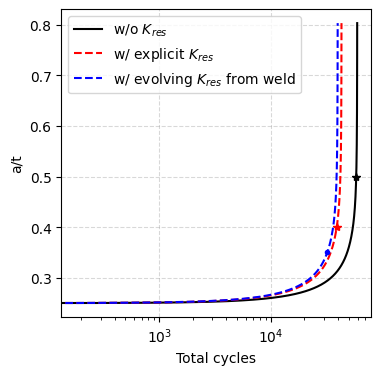

In [6]:
fig, ax1 = plt.subplots(figsize=(4,4))
ax1.plot(analysis_wo_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_wo_kres_det.nominal_load_cycling[0]['a/t'],
         'k-', label=r'w/o $K_{res}$')
ax1.plot(analysis_wo_kres_det.nominal_life_criteria['Cycles to a(crit)'][0],
         analysis_wo_kres_det.nominal_life_criteria['Cycles to a(crit)'][1],
         'k*')

ax1.plot(analysis_w_exp_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_exp_kres_det.nominal_load_cycling[0]['a/t'],
         'r--', label=r'w/ explicit $K_{res}$')
ax1.plot(analysis_w_exp_kres_det.nominal_life_criteria['Cycles to a(crit)'][0],
         analysis_w_exp_kres_det.nominal_life_criteria['Cycles to a(crit)'][1],
         'r*')

ax1.plot(analysis_w_weld_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_weld_det.nominal_load_cycling[0]['a/t'],
         'b--', label=r'w/ evolving $K_{res}$ from weld')
ax1.plot(analysis_w_weld_det.nominal_life_criteria['Cycles to a(crit)'][0],
         analysis_w_weld_det.nominal_life_criteria['Cycles to a(crit)'][1],
         'b.')

ax1.set_xlabel('Total cycles')
ax1.set_ylabel('a/t')

ax1.set_xscale('log')

ax1.legend(loc=0)
plt.grid(color='gray', alpha=0.3, linestyle='--')

              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles       58168.074078               1.000000      29084.037039   
a/t                    0.499076               0.124769          0.288095   

              Cycles to FAD line  
Total cycles        56495.856587  
a/t                     0.437057  
              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles       38931.506596               1.000000      19465.753298   
a/t                    0.400062               0.100015          0.285647   

              Cycles to FAD line  
Total cycles        23220.301262  
a/t                     0.296395  
              Cycles to a(crit)  Cycles to 25% a(crit)  Cycles to 1/2 Nc  \
Total cycles       32129.347790               1.000000      16064.673895   
a/t                    0.350875               0.087719          0.279793   

              Cycles to FAD line  
Total cycles         7751.442225  
a/t                     0.262253 

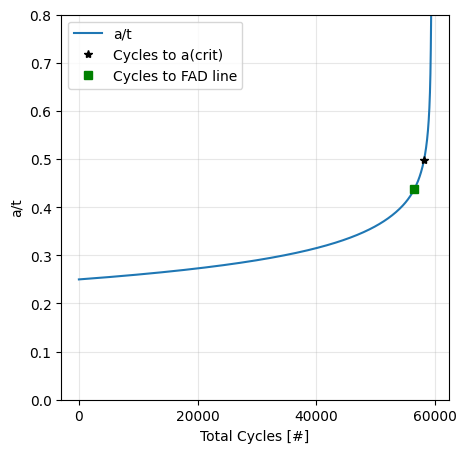

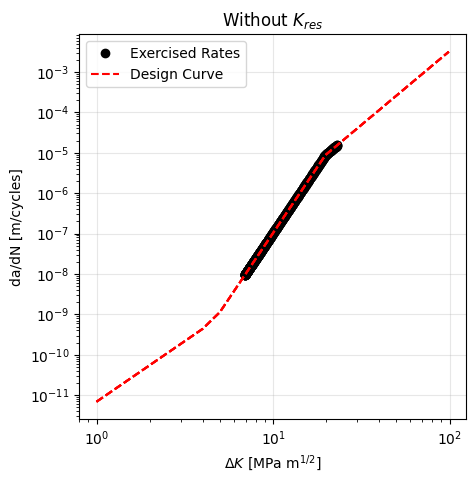

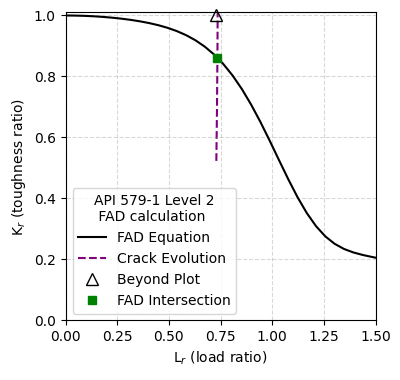

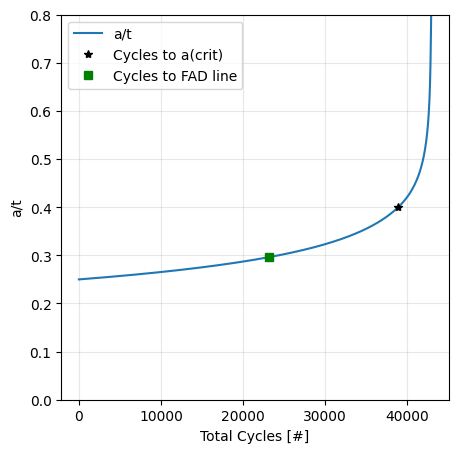

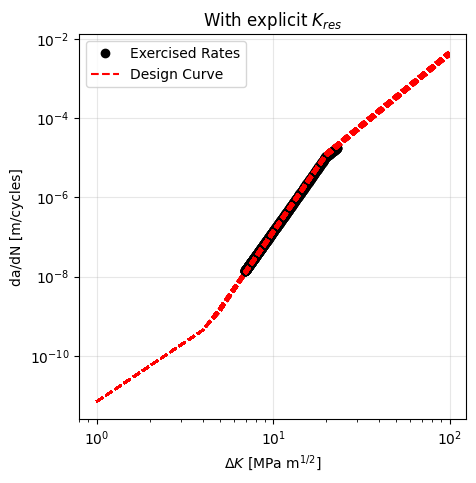

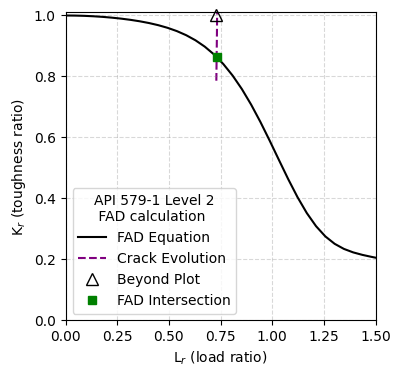

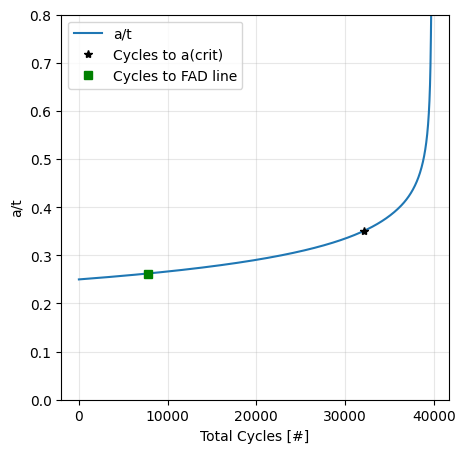

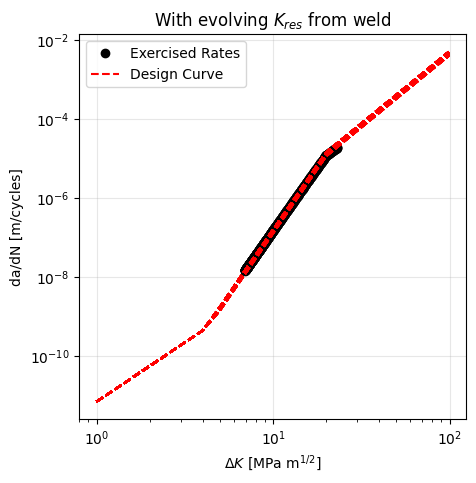

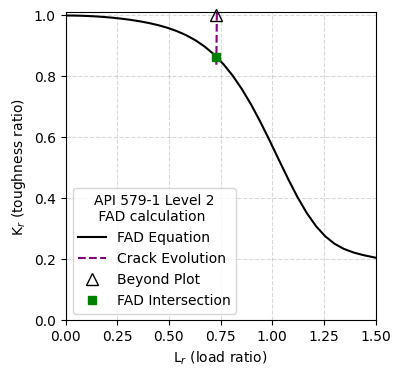

In [7]:
analysis_wo_kres_det.postprocess_single_crack_results()
analysis_wo_kres_det.get_design_curve_plot()
plt.title(r'Without $K_{res}$')
_, _ = analysis_wo_kres_det.assemble_failure_assessment_diagram()

analysis_w_exp_kres_det.postprocess_single_crack_results()
analysis_w_exp_kres_det.get_design_curve_plot()
plt.title(r'With explicit $K_{res}$')
_, _ = analysis_w_exp_kres_det.assemble_failure_assessment_diagram()

analysis_w_weld_det.postprocess_single_crack_results()
analysis_w_weld_det.get_design_curve_plot()
plt.title(r'With evolving $K_{res}$ from weld')
_, _ = analysis_w_weld_det.assemble_failure_assessment_diagram()


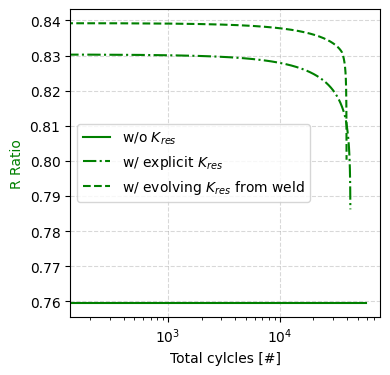

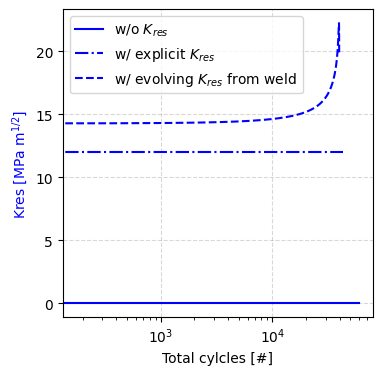

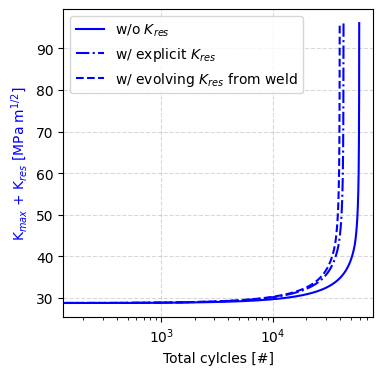

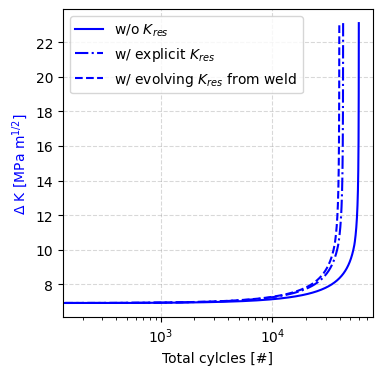

In [8]:
fig = plt.figure(figsize=(4, 4))
plt.plot(analysis_wo_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_wo_kres_det.nominal_load_cycling[0]['R ratio'],
         'g-', label=r'w/o $K_{res}$')
plt.plot(analysis_w_exp_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_exp_kres_det.nominal_load_cycling[0]['R ratio'],
         'g-.', label=r'w/ explicit $K_{res}$')
plt.plot(analysis_w_weld_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_weld_det.nominal_load_cycling[0]['R ratio'],
         'g--', label=r'w/ evolving $K_{res}$ from weld')
plt.xlabel('Total cylcles [#]')
plt.ylabel('R Ratio', color='green')
plt.xscale('log')
plt.grid(color='gray', alpha=0.3, linestyle='--')
plt.legend(loc=0)

fig = plt.figure(figsize=(4,4))
plt.plot(analysis_wo_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_wo_kres_det.nominal_load_cycling[0]['Kres (MPa m^1/2)'],
         'b-', label=r'w/o $K_{res}$')
plt.plot(analysis_w_exp_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_exp_kres_det.nominal_load_cycling[0]['Kres (MPa m^1/2)'],
         'b-.', label=r'w/ explicit $K_{res}$')
plt.plot(analysis_w_weld_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_weld_det.nominal_load_cycling[0]['Kres (MPa m^1/2)'],
         'b--', label=r'w/ evolving $K_{res}$ from weld')

plt.xlabel('Total cylcles [#]')
plt.ylabel('Kres [MPa m$^{1/2}$]', color='blue')
plt.xscale('log')
plt.grid(color='gray', alpha=0.3, linestyle='--')
plt.legend(loc=0)


fig = plt.figure(figsize=(4,4))
plt.plot(analysis_wo_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_wo_kres_det.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
         'b-', label=r'w/o $K_{res}$')
plt.plot(analysis_w_exp_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_exp_kres_det.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
         'b-.', label=r'w/ explicit $K_{res}$')
plt.plot(analysis_w_weld_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_weld_det.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
         'b--', label=r'w/ evolving $K_{res}$ from weld')

plt.xlabel('Total cylcles [#]')
plt.ylabel(r'K$_{max}$ + K$_{res}$ [MPa m$^{1/2}$]', color='blue')
plt.xscale('log')
plt.grid(color='gray', alpha=0.3, linestyle='--')
plt.legend(loc=0)


fig = plt.figure(figsize=(4,4))
plt.plot(analysis_wo_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_wo_kres_det.nominal_load_cycling[0]['Delta K (MPa m^1/2)'],
         'b-', label=r'w/o $K_{res}$')
plt.plot(analysis_w_exp_kres_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_exp_kres_det.nominal_load_cycling[0]['Delta K (MPa m^1/2)'],
         'b-.', label=r'w/ explicit $K_{res}$')
plt.plot(analysis_w_weld_det.nominal_load_cycling[0]['Total cycles'],
         analysis_w_weld_det.nominal_load_cycling[0]['Delta K (MPa m^1/2)'],
         'b--', label=r'w/ evolving $K_{res}$ from weld')

plt.xlabel('Total cylcles [#]')
plt.ylabel(r'$\Delta$ K [MPa m$^{1/2}$]', color='blue')
plt.xscale('log')
plt.grid(color='gray', alpha=0.3, linestyle='--')
plt.legend(loc=0);

/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_25346/1506651364.py:3: RuntimeWarning: invalid value encountered in divide
  np.array(analysis_wo_kres_det.nominal_load_cycling[0]['Delta a (m)'])/\
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_25346/1506651364.py:7: RuntimeWarning: invalid value encountered in divide
  np.array(analysis_w_exp_kres_det.nominal_load_cycling[0]['Delta a (m)'])/\
/var/folders/m7/xj3t74md7k32bgn0f0bvz3mr002lyh/T/ipykernel_25346/1506651364.py:11: RuntimeWarning: invalid value encountered in divide
  np.array(analysis_w_weld_det.nominal_load_cycling[0]['Delta a (m)'])/\


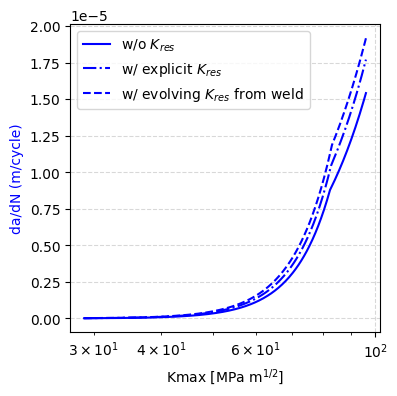

In [9]:
fig = plt.figure(figsize=(4,4))
plt.plot(analysis_wo_kres_det.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
        np.array(analysis_wo_kres_det.nominal_load_cycling[0]['Delta a (m)'])/\
            np.array(analysis_wo_kres_det.nominal_load_cycling[0]['Delta N']),
         'b-',  label=r'w/o $K_{res}$')
plt.plot(analysis_w_exp_kres_det.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
         np.array(analysis_w_exp_kres_det.nominal_load_cycling[0]['Delta a (m)'])/\
            np.array(analysis_w_exp_kres_det.nominal_load_cycling[0]['Delta N']),
         'b-.',  label=r'w/ explicit $K_{res}$')
plt.plot(analysis_w_weld_det.nominal_load_cycling[0]['Kmax (MPa m^1/2)'],
         np.array(analysis_w_weld_det.nominal_load_cycling[0]['Delta a (m)'])/\
            np.array(analysis_w_weld_det.nominal_load_cycling[0]['Delta N']),
         'b--', label=r'w/ evolving $K_{res}$ from weld')

plt.xlabel(r'Kmax [MPa m$^{1/2}$]')
plt.ylabel('da/dN (m/cycle)', color='blue')
plt.xscale('log')
plt.grid(color='gray', alpha=0.3, linestyle='--')
plt.legend(loc=0);

### Probabilistic Analysis

In [10]:
sample_type = 'lhs'
sample_size = 100
plotted_variable = 'Cycles to a(crit)'

In [11]:
weld_thickness_prob = TruncatedNormalDistribution(
            name='weld_thickness',
            uncertainty_type='aleatory',
            nominal_value=0.01,
            mean=0.01,
            std_deviation=0.005,
            lower_bound=0.001,
            upper_bound=0.02)
weld_yield_strength_prob = BetaDistribution(
            name='weld_yield_strength',
            uncertainty_type='aleatory',
            nominal_value=convert_psi_to_mpa(52_000),
            a=0.5,
            b=2,
            loc=convert_psi_to_mpa(52_000),
            scale=1)
weld_flaw_distance_prob = UniformDistribution(
            name='weld_flaw_distance',
            uncertainty_type='aleatory',
            nominal_value=0.02*3,
            lower_bound=0.02*.5,
            upper_bound=0.02*4.5)

k_res_explicit_prob = NormalDistribution(
            name='residual_stress_intensity_factor',
            uncertainty_type='aleatory',
            nominal_value=12.,
            mean=12.,
            std_deviation=2)

In [12]:
analysis_w_exp_kres_prob = CrackEvolutionAnalysis(outer_diameter=pipe_outer_diameter,
                                  wall_thickness=wall_thickness,
                                  flaw_depth=flaw_depth,
                                  max_pressure=max_pressure,
                                  min_pressure=min_pressure,
                                  temperature=temperature,
                                  volume_fraction_h2=volume_fraction_h2,
                                  yield_strength=yield_strength,
                                  fracture_resistance=fracture_resistance,
                                  flaw_length=flaw_length,
                                  stress_intensity_method=stress_intensity_method,
                                  surface=surface,
                                  residual_stress_intensity_factor=k_res_explicit_prob,
                                  aleatory_samples=sample_size,
                                  sample_type=sample_type,
                                  fad_type='API 579-1 Level 2')
analysis_w_exp_kres_prob.perform_study()

analysis_w_weld_prob = CrackEvolutionAnalysis(outer_diameter=pipe_outer_diameter,
                                  wall_thickness=wall_thickness,
                                  flaw_depth=flaw_depth,
                                  max_pressure=max_pressure,
                                  min_pressure=min_pressure,
                                  temperature=temperature,
                                  volume_fraction_h2=volume_fraction_h2,
                                  yield_strength=yield_strength,
                                  fracture_resistance=fracture_resistance,
                                  flaw_length=flaw_length,
                                  stress_intensity_method=stress_intensity_method,
                                  surface=surface,
                                  weld_thickness=weld_thickness_prob,
                                  weld_yield_strength=weld_yield_strength_prob,
                                  weld_flaw_distance=weld_flaw_distance_prob,
                                  weld_flaw_direction=flaw_direction,
                                  weld_steel=weld_steel,
                                  weld_process=weld_process,
                                  aleatory_samples=sample_size,
                                  sample_type=sample_type,
                                  fad_type='API 579-1 Level 2')
analysis_w_weld_prob.perform_study()

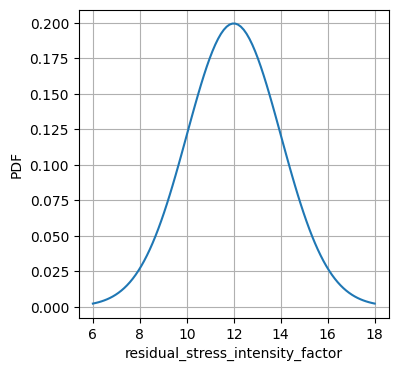

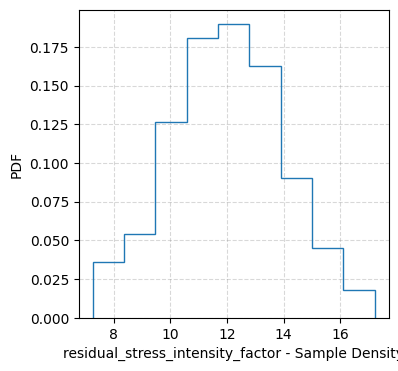

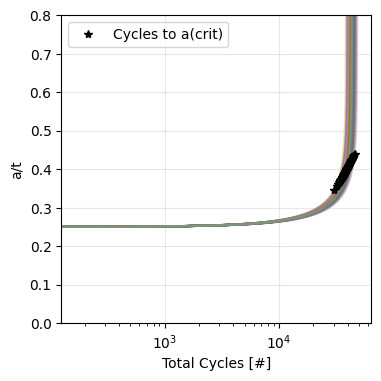

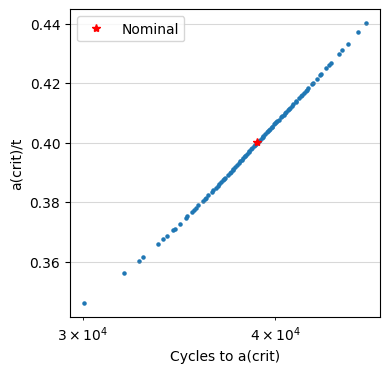

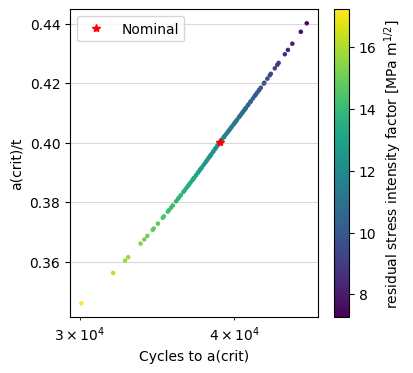

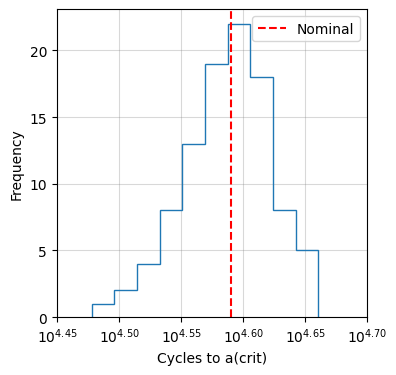

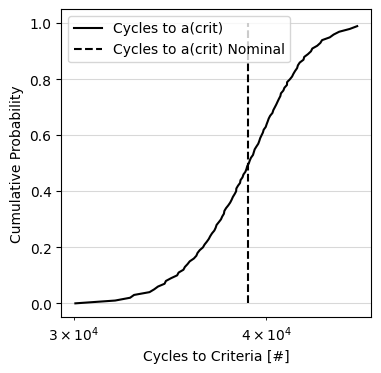

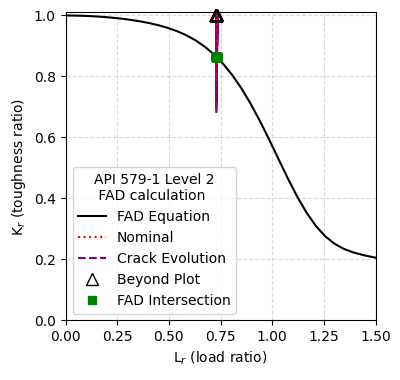

In [13]:
for parameter in analysis_w_exp_kres_prob.uncertain_parameters:

    analysis_w_exp_kres_prob.input_parameters[parameter].plot_distribution()

    plot_sample_histogram(analysis_w_exp_kres_prob.sampling_input_parameter_values[parameter],
                          f'{parameter} - Sample Density',
                          density=True,
                          histtype='step')

analysis_w_exp_kres_prob.generate_probabilistic_results_plots(plotted_variable=[plotted_variable])
_, _ = analysis_w_exp_kres_prob.assemble_failure_assessment_diagram()

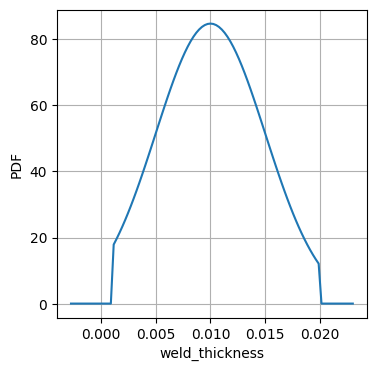

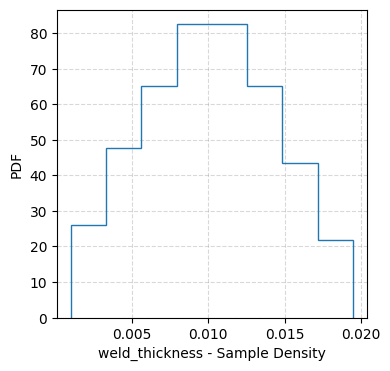

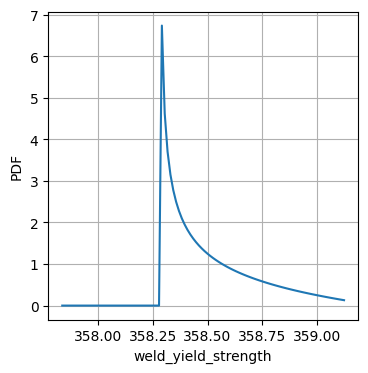

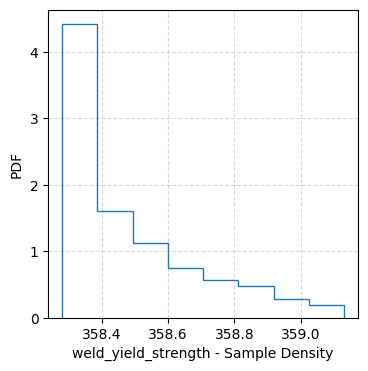

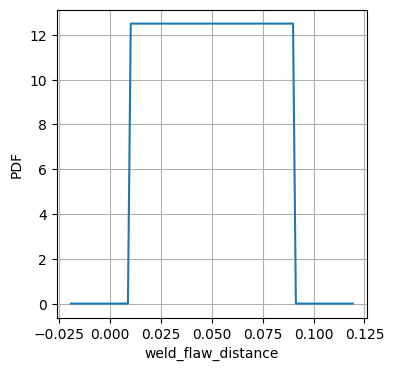

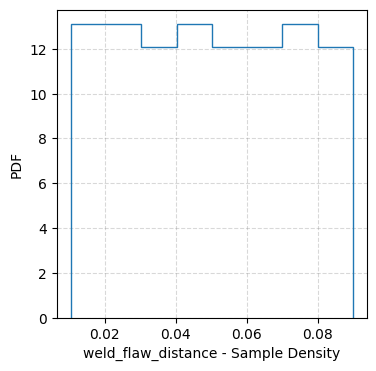

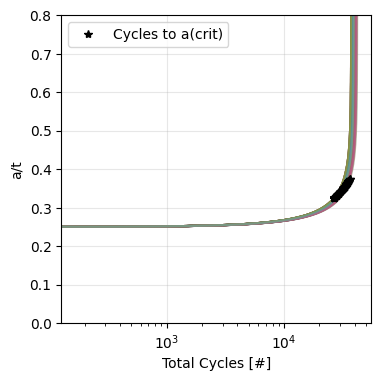

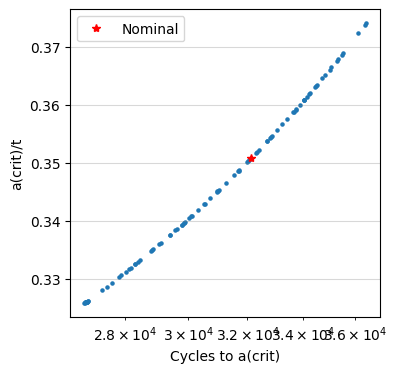

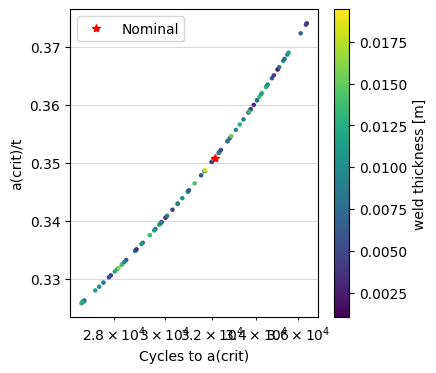

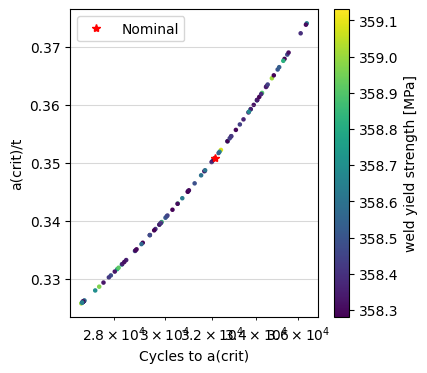

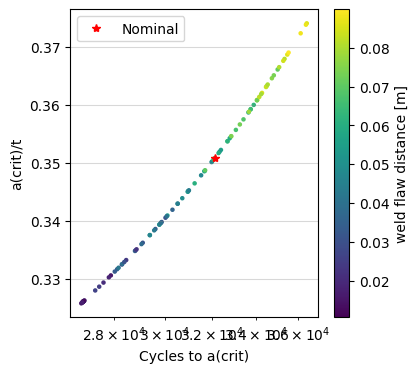

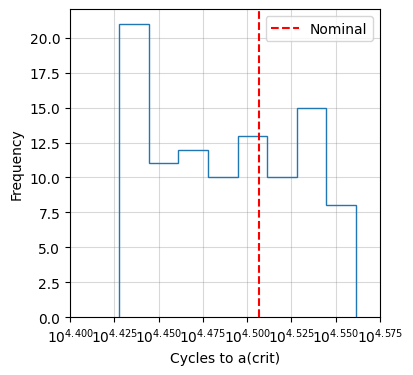

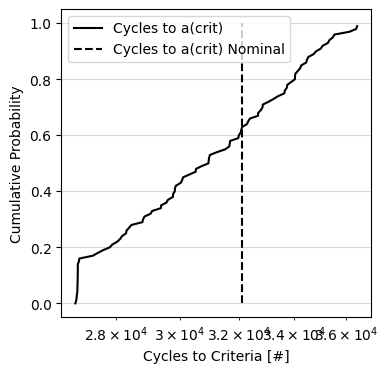

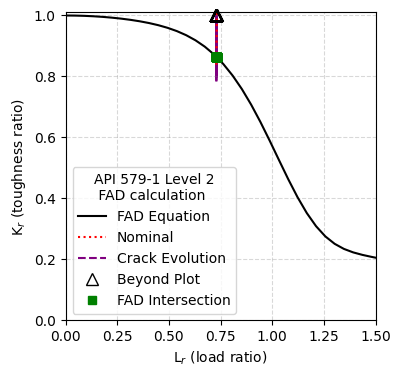

In [14]:
for parameter in analysis_w_weld_prob.uncertain_parameters:

    analysis_w_weld_prob.input_parameters[parameter].plot_distribution()

    plot_sample_histogram(analysis_w_weld_prob.sampling_input_parameter_values[parameter],
                          f'{parameter} - Sample Density',
                          density=True,
                          histtype='step')

analysis_w_weld_prob.generate_probabilistic_results_plots(plotted_variable=[plotted_variable])
_, _ = analysis_w_weld_prob.assemble_failure_assessment_diagram()

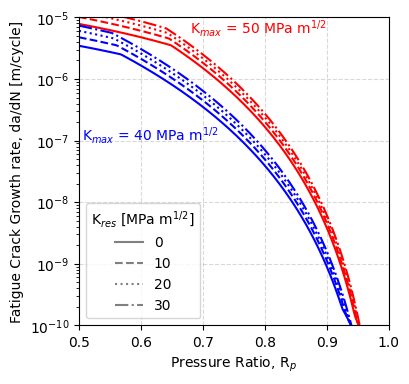

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from helpr.physics.environment import EnvironmentSpecification
from helpr.physics.crack_growth import CrackGrowth


def get_da_dn(r_p,
              k_res,
              k_max, 
              delta_a=1e-6):

    crack_growth_model={'model_name': 'code_case_2938'}

    environment = EnvironmentSpecification(max_pressure=10,
                                            min_pressure=1,
                                            temperature=293,
                                            volume_fraction_h2=1)

    crack_growth = CrackGrowth(environment=environment,
                               growth_model_specification=crack_growth_model)


    k_min = k_max * r_p
    r_k = (k_min + k_res)/(k_max + k_res)
    delta_k = (k_max + k_res)*(1 - r_k)

    # G = 5.5 # MPa m^1/2
    # I = 5.5 # MPa m^1/2
    # H = 0.8
    # delta_k_th = min(G*(1 - H*r_k), I)

    da_dn = delta_a/crack_growth.calc_delta_n(delta_a=delta_a, delta_k=delta_k, r_ratio=r_k)

    return da_dn


all_results_40 = {0:[], 10: [], 20: []}
all_results_50 = {0:[], 10: [], 20: []}
r_p = np.linspace(0.5, .96, 200)
k_res = [0, 10, 20, 30]
for kres in k_res:
    temp_40 = []
    temp_50 = []
    for rp in r_p:
        da_dn = get_da_dn(r_p=rp, k_res=kres, k_max=40)
        temp_40.append(da_dn)
        da_dn = get_da_dn(r_p=rp, k_res=kres, k_max=50)
        temp_50.append(da_dn)

    all_results_40[kres] = temp_40
    all_results_50[kres] = temp_50

df_40 = pd.DataFrame(all_results_40)
df_50 = pd.DataFrame(all_results_50)


plt.figure(figsize=(4, 4))
for ls, kres in zip(['-', '--', ':', '-.'], k_res):
    plt.plot([], [], linestyle=ls, color='gray', label=kres)
    plt.plot(r_p, df_50[kres], linestyle=ls, color='red')
    plt.plot(r_p, df_40[kres], linestyle=ls, color='blue')

plt.text(0.45, 0.6, 'K$_{max}$ = 40 MPa m$^{1/2}$', fontsize=10,
         color='blue', ha='right', transform=plt.gca().transAxes)
plt.text(0.8, 0.95, 'K$_{max}$ = 50 MPa m$^{1/2}$', fontsize=10,
         color='red', ha='right', transform=plt.gca().transAxes)
plt.xlabel(r'Pressure Ratio, R$_p$')
plt.ylabel('Fatigue Crack Growth rate, da/dN [m/cycle]')
plt.legend(loc=0, title='K$_{res}$ [MPa m$^{1/2}$]')
plt.yscale('log')
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.xlim(0.5, 1)
plt.ylim(1e-10, 1e-5);
        